<a href="https://colab.research.google.com/github/sravanya-2006/space-weather-ai-guardian/blob/main/models/04_model_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/sravanya-2006/space-weather-ai-guardian.git

Cloning into 'space-weather-ai-guardian'...
remote: Enumerating objects: 29, done.
remote: Counting objects: 100% (29/29), done.
remote: Compressing objects: 100% (21/21), done.
remote: Total 29 (delta 6), reused 11 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (29/29), 96.70 KiB | 2.20 MiB/s, done.
Resolving deltas: 100% (6/6), done.


In [2]:
%cd space-weather-ai-guardian

/content/space-weather-ai-guardian


In [3]:
!pip install xgboost

In [4]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from xgboost import XGBClassifier

import joblib

In [5]:
from google.colab import files

uploaded = files.upload()

Saving final_features.csv to final_features.csv


In [6]:
df = pd.read_csv("final_features.csv")

df.head()

,flrID,catalog,instruments,beginTime,peakTime,endTime,classType,sourceLocation,activeRegionNum,submissionTime,...,duration_minutes,flare_class,risk_level,hour,day,month,year,day_of_week,magnitude,flare_class_encoded
0,2024-01-01T08:33:00-FLR-001,M2M_CATALOG,[{'displayName': 'GOES-P: EXIS 1.0-8.0'}],2024-01-01 08:33:00+00:00,2024-01-01 08:54:00+00:00,2024-01-01 09:04:00+00:00,M2.3,N03E70,13536.0,2024-01-01 13:28:00+00:00,...,31.0,M,2,8,1,1,2024,0,2.3,1
1,2024-01-01T11:54:00-FLR-001,M2M_CATALOG,[{'displayName': 'GOES-P: EXIS 1.0-8.0'}],2024-01-01 11:54:00+00:00,2024-01-01 12:25:00+00:00,2024-01-01 12:35:00+00:00,M4.7,N03E68,13536.0,2024-01-01 13:24:00+00:00,...,41.0,M,2,11,1,1,2024,0,4.7,1
2,2024-01-02T18:02:00-FLR-001,M2M_CATALOG,[{'displayName': 'GOES-P: EXIS 1.0-8.0'}],2024-01-02 18:02:00+00:00,2024-01-02 18:30:00+00:00,2024-01-02 18:56:00+00:00,M1.1,N05E59,13536.0,2024-01-02 19:34:00+00:00,...,54.0,M,2,18,2,1,2024,1,1.1,1
3,2024-01-04T01:08:00-FLR-001,M2M_CATALOG,[{'displayName': 'GOES-P: EXIS 1.0-8.0'}],2024-01-04 01:08:00+00:00,2024-01-04 01:16:00+00:00,2024-01-04 01:22:00+00:00,M1.1,N02E38,13536.0,2024-01-04 01:44:00+00:00,...,14.0,M,2,1,4,1,2024,3,1.1,1
4,2024-01-04T01:22:00-FLR-001,M2M_CATALOG,[{'displayName': 'GOES-P: EXIS 1.0-8.0'}],2024-01-04 01:22:00+00:00,2024-01-04 01:55:00+00:00,2024-01-04 02:12:00+00:00,M3.8,N04E38,13536.0,2024-01-04 03:00:00+00:00,...,50.0,M,2,1,4,1,2024,3,3.8,1


In [7]:
df.shape

(1128, 22)

In [8]:
df.columns

Index(['flrID', 'catalog', 'instruments', 'beginTime', 'peakTime', 'endTime',
       'classType', 'sourceLocation', 'activeRegionNum', 'submissionTime',
       'versionId', 'linkedEvents', 'duration_minutes', 'flare_class',
       'risk_level', 'hour', 'day', 'month', 'year', 'day_of_week',
       'magnitude', 'flare_class_encoded'],
      dtype='object')

In [9]:
features = [
    "magnitude",
    "duration_minutes",
    "hour",
    "day",
    "month",
    "year",
    "day_of_week",
    "flare_class_encoded"
]

X = df[features]

y = df["risk_level"]

In [15]:
y = df["risk_level"] - 1

In [16]:
y.value_counts()

,count
risk_level,
1,982
0,92
2,54


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [18]:
model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [20]:
y_pred = model.predict(X_test)

In [21]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [29]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(
    y_test,
    y_pred,
    target_names=["Low", "Medium", "High"],
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

report_df

,precision,recall,f1-score,support
Low,1.0,1.0,1.0,18.0
Medium,1.0,1.0,1.0,197.0
High,1.0,1.0,1.0,11.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,226.0
weighted avg,1.0,1.0,1.0,226.0


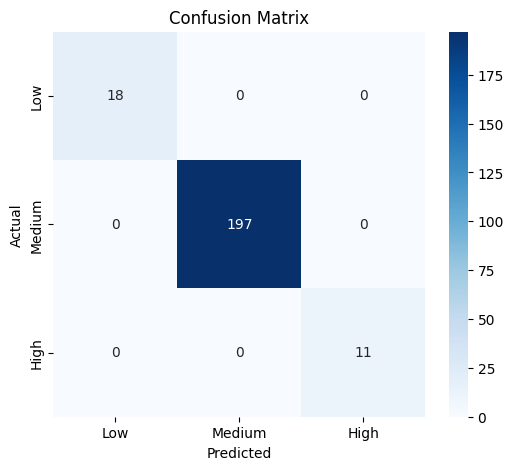

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Low", "Medium", "High"],
    yticklabels=["Low", "Medium", "High"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

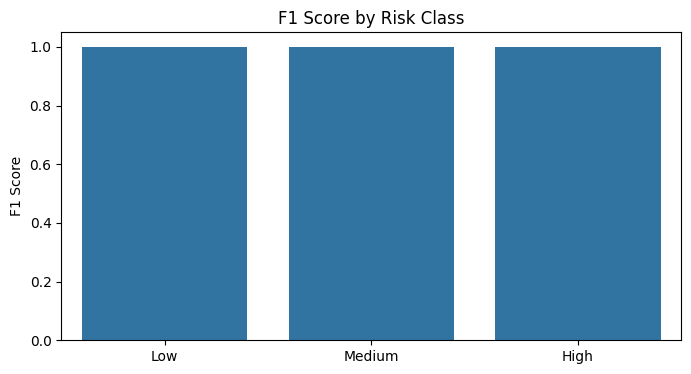

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

sns.barplot(
    x=["Low", "Medium", "High"],
    y=report_df.loc[
        ["Low", "Medium", "High"],
        "f1-score"
    ]
)

plt.title("F1 Score by Risk Class")
plt.ylabel("F1 Score")
plt.ylim(0, 1.05)

plt.show()

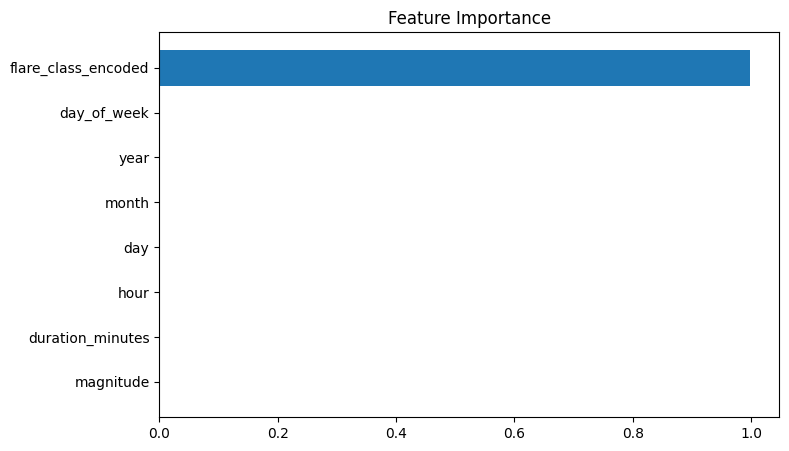

In [30]:
import matplotlib.pyplot as plt

importance = model.feature_importances_

plt.figure(figsize=(8,5))

plt.barh(
    X.columns,
    importance
)

plt.title("Feature Importance")

plt.show()

In [31]:
joblib.dump(model, "risk_model.pkl")

['risk_model.pkl']

In [32]:
import joblib

joblib.dump(
    model,
    "risk_model.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


In [34]:
!ls

data		    LICENSE    README.md	 risk_model.pkl  test.py
final_features.csv  notebooks  requirements.txt  src


In [35]:
from google.colab import files

files.download("risk_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>